# Model results

This notebook compares the four runs produced by `scripts/train.py`: the TF-IDF baseline and three DistilBERT data-efficiency runs.

## Run training once (only if needed)

Run the next cell only when `../outputs/results.csv` is missing or you want fresh experiment results. If you have already run `train.py` and the outputs are present, skip it: training the three DistilBERT runs takes time.

In [ ]:
# Run only if the saved outputs are missing or need to be regenerated.
!cd .. && python scripts/train.py

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
RESULTS_PATH = Path('../outputs/results.csv')
if not RESULTS_PATH.exists():
    raise FileNotFoundError('Run `python ../scripts/train.py` from this notebooks directory first.')

results = pd.read_csv(RESULTS_PATH)

In [2]:
def display_name(row):
    if row['model'] == 'tfidf-logistic':
        return 'TF-IDF + Logistic Regression'
    return f"DistilBERT ({row['fraction']:.0%} data)"

results['run'] = results.apply(display_name, axis=1)
comparison = results[['run', 'accuracy', 'macro_f1']].sort_values('macro_f1', ascending=False)
comparison.style.format({'accuracy': '{:.3f}', 'macro_f1': '{:.3f}'})

,run,accuracy,macro_f1
3,DistilBERT (100% data),0.899,0.899
1,DistilBERT (10% data),0.870,0.870
2,DistilBERT (25% data),0.857,0.855
0,TF-IDF + Logistic Regression,0.855,0.854


## Four-run comparison

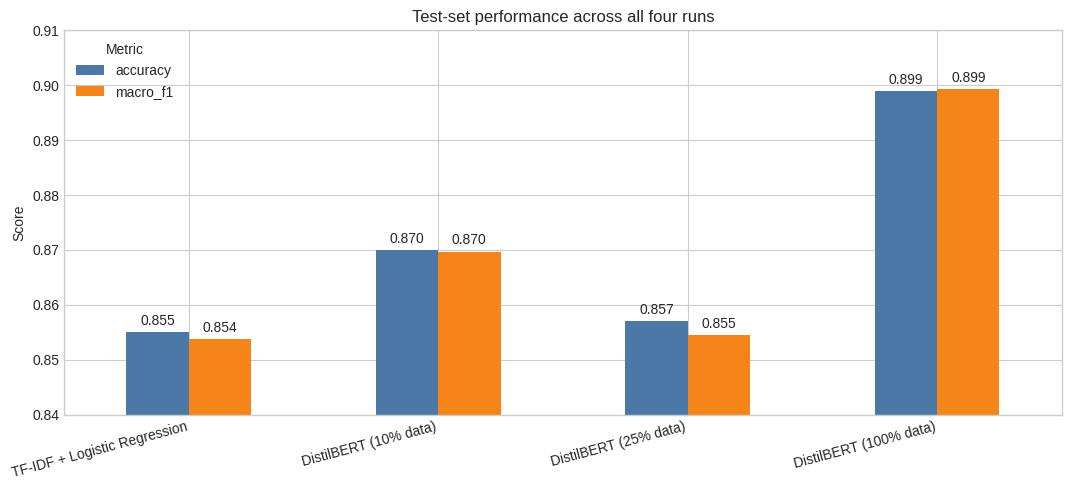

In [3]:
plot_data = results.set_index('run')[['accuracy', 'macro_f1']]
ax = plot_data.plot.bar(figsize=(11, 5), color=['#4C78A8', '#F58518'])
ax.set(title='Test-set performance across all four runs', xlabel='', ylabel='Score', ylim=(0.84, 0.91))
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3)
plt.xticks(rotation=15, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

## DistilBERT data efficiency

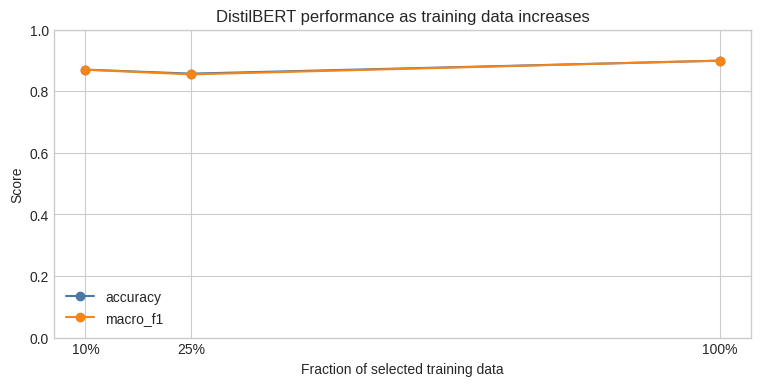

Best run: DistilBERT (100% data) (macro-F1 0.899).
Best DistilBERT run changes macro-F1 by +0.045 relative to the TF-IDF baseline.


In [4]:
bert = results.query("model == 'distilbert'").sort_values('fraction')
ax = bert.plot(x='fraction', y=['accuracy', 'macro_f1'], marker='o', figsize=(9, 4), color=['#4C78A8', '#F58518'])
ax.set(title='DistilBERT performance as training data increases', xlabel='Fraction of selected training data', ylabel='Score', ylim=(0, 1))
ax.set_xticks(bert['fraction'], [f'{value:.0%}' for value in bert['fraction']])
plt.show()

best = comparison.iloc[0]
baseline = results.loc[results['model'].eq('tfidf-logistic'), 'macro_f1'].iloc[0]
print(f"Best run: {best['run']} (macro-F1 {best['macro_f1']:.3f}).")
print(f"Best DistilBERT run changes macro-F1 by {bert['macro_f1'].max() - baseline:+.3f} relative to the TF-IDF baseline.")